# 제조업 센서 데이터

In [1]:
import os
import pandas as pd
import numpy as np
from plt_rcs import *
import hds

In [2]:
plt.rc(group='figure', figsize=(4, 4), dpi=120)

In [4]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/ml_part2'

In [5]:
os.chdir('../../data')

In [7]:
[i for i in os.listdir() if 'Sensor' in i][0]

'FacilitySensor.txt'

In [8]:
df = pd.read_csv('FacilitySensor.txt')

In [9]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [11]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

## 기술통계량 확인

In [12]:
df.describe().round(3)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5000.500,300.005,310.006,1538.776,39.987,107.951,0.034
std,2886.896,2.000,1.484,179.284,9.969,63.654,0.181
min,1.000,295.300,305.700,1168.000,3.800,0.000,0.000
25%,2500.750,298.300,308.800,1423.000,33.200,53.000,0.000
50%,5000.500,300.100,310.100,1503.000,40.100,108.000,0.000
75%,7500.250,301.500,311.100,1612.000,46.800,162.000,0.000
max,10000.000,304.500,313.800,2886.000,76.600,253.000,1.000


In [13]:
df.describe(include=object)

,Product ID,Type,Failure Type
count,10000,10000,10000
unique,10000,3,6
top,M14860,L,No Failure
freq,1,6000,9652


In [14]:
df['Type'].value_counts().sort_index()

Type
H    1003
L    6000
M    2997
Name: count, dtype: int64

In [15]:
df['Failure Type'].value_counts().sort_index()

Failure Type
Heat Dissipation Failure     112
No Failure                  9652
Overstrain Failure            78
Power Failure                 95
Random Failures               18
Tool Wear Failure             45
Name: count, dtype: int64

In [16]:
df[['Target', 'Failure Type']].value_counts().sort_index()

Target  Failure Type            
0       No Failure                  9643
        Random Failures               18
1       Heat Dissipation Failure     112
        No Failure                     9
        Overstrain Failure            78
        Power Failure                 95
        Tool Wear Failure             45
Name: count, dtype: int64

## 데이터 전처리

In [18]:
df = df.drop(columns=['UDI', 'Failure Type']).set_index(keys='Product ID')
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
Product ID,,,,,,,
M14860,M,298.1,308.6,1551,42.8,0,0
L47181,L,298.2,308.7,1408,46.3,3,0
L47182,L,298.1,308.5,1498,49.4,5,0
L47183,L,298.2,308.6,1433,39.5,7,0
L47184,L,298.2,308.7,1408,40.0,9,0


In [19]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target'],
      dtype='object')

In [20]:
df.columns = ['Type', 'AirTmp', 'ProcTmp', 'RotSpd', 'Torque', 'ToolWear', 'Target']

In [21]:
df.head()

,Type,AirTmp,ProcTmp,RotSpd,Torque,ToolWear,Target
Product ID,,,,,,,
M14860,M,298.1,308.6,1551,42.8,0,0
L47181,L,298.2,308.7,1408,46.3,3,0
L47182,L,298.1,308.5,1498,49.4,5,0
L47183,L,298.2,308.6,1433,39.5,7,0
L47184,L,298.2,308.7,1408,40.0,9,0


## EDA

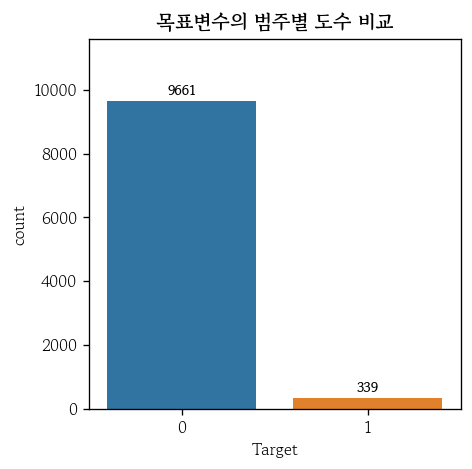

In [22]:
hds.plot.bar_freq(data=df, x='Target')

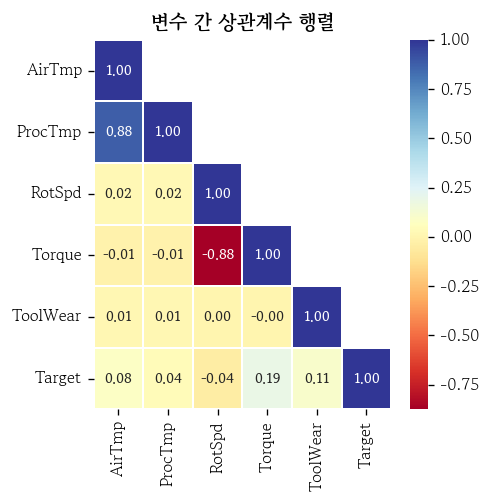

In [24]:
hds.plot.corr_heatmap(data=df)
plt.yticks(rotation=0)
plt.show()

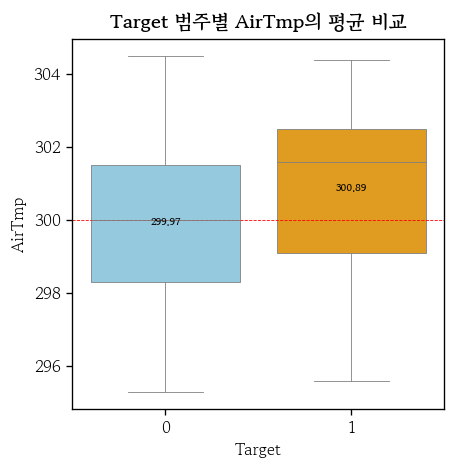

In [25]:
hds.plot.box_group(
    data=df, x='Target', y='AirTmp',
    palette=['skyblue', 'orange']
)

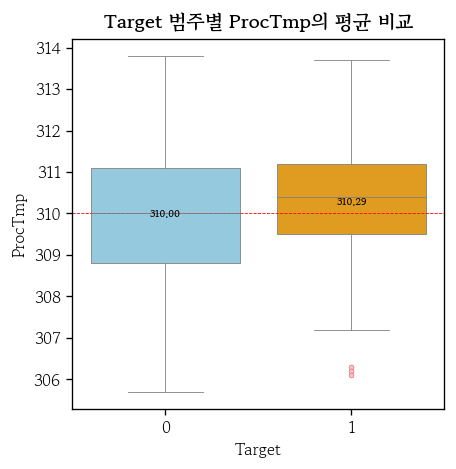

In [26]:
hds.plot.box_group(
    data=df, x='Target', y='ProcTmp',
    palette=['skyblue', 'orange']
)

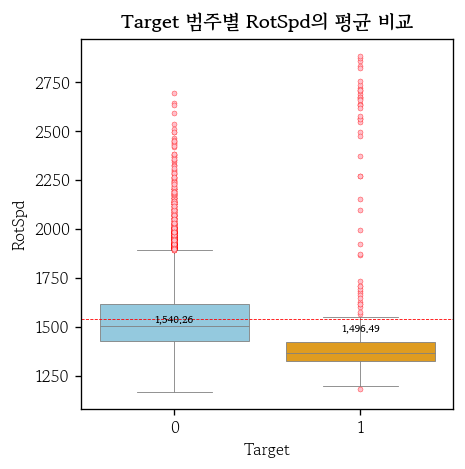

In [27]:
hds.plot.box_group(
    data=df, x='Target', y='RotSpd',
    palette=['skyblue', 'orange']
)

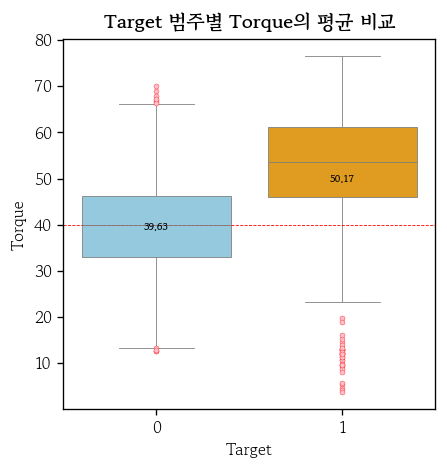

In [28]:
hds.plot.box_group(
    data=df, x='Target', y='Torque',
    palette=['skyblue', 'orange']
)

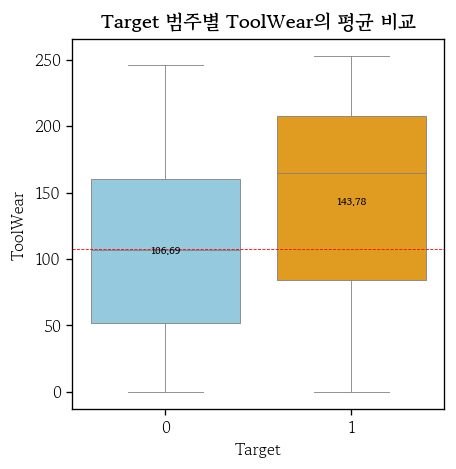

In [29]:
hds.plot.box_group(
    data=df, x='Target', y='ToolWear',
    palette=['skyblue', 'orange']
)

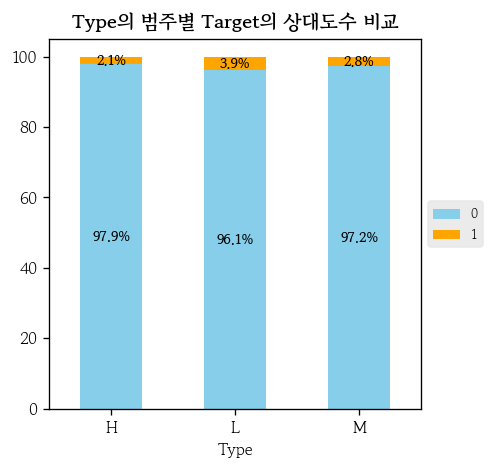

In [30]:
hds.plot.bar_stack_prop(data=df, x='Type', g='Target', palette=['skyblue', 'orange'])

## 오디널 인코딩

In [31]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
oe = OrdinalEncoder(categories=[['L', 'M', 'H']], dtype=int)
# df['Type'] = oe.fit_transform(X=df[['Type']])[:, 0] + 1

In [35]:
# 수동 매핑
type_map = {
    'L': 1,
    'M': 2,
    'H': 3
}
df['Type'] = df['Type'].map(type_map)

In [36]:
df['Type'].value_counts().sort_index()

Type
1    6000
2    2997
3    1003
Name: count, dtype: int64

## 산점도 행렬 시각화

In [37]:
df.head()

,Type,AirTmp,ProcTmp,RotSpd,Torque,ToolWear,Target
Product ID,,,,,,,
M14860,2,298.1,308.6,1551,42.8,0,0
L47181,1,298.2,308.7,1408,46.3,3,0
L47182,1,298.1,308.5,1498,49.4,5,0
L47183,1,298.2,308.6,1433,39.5,7,0
L47184,1,298.2,308.7,1408,40.0,9,0


In [38]:
train_num = df.drop(columns=['Type', 'Target'])

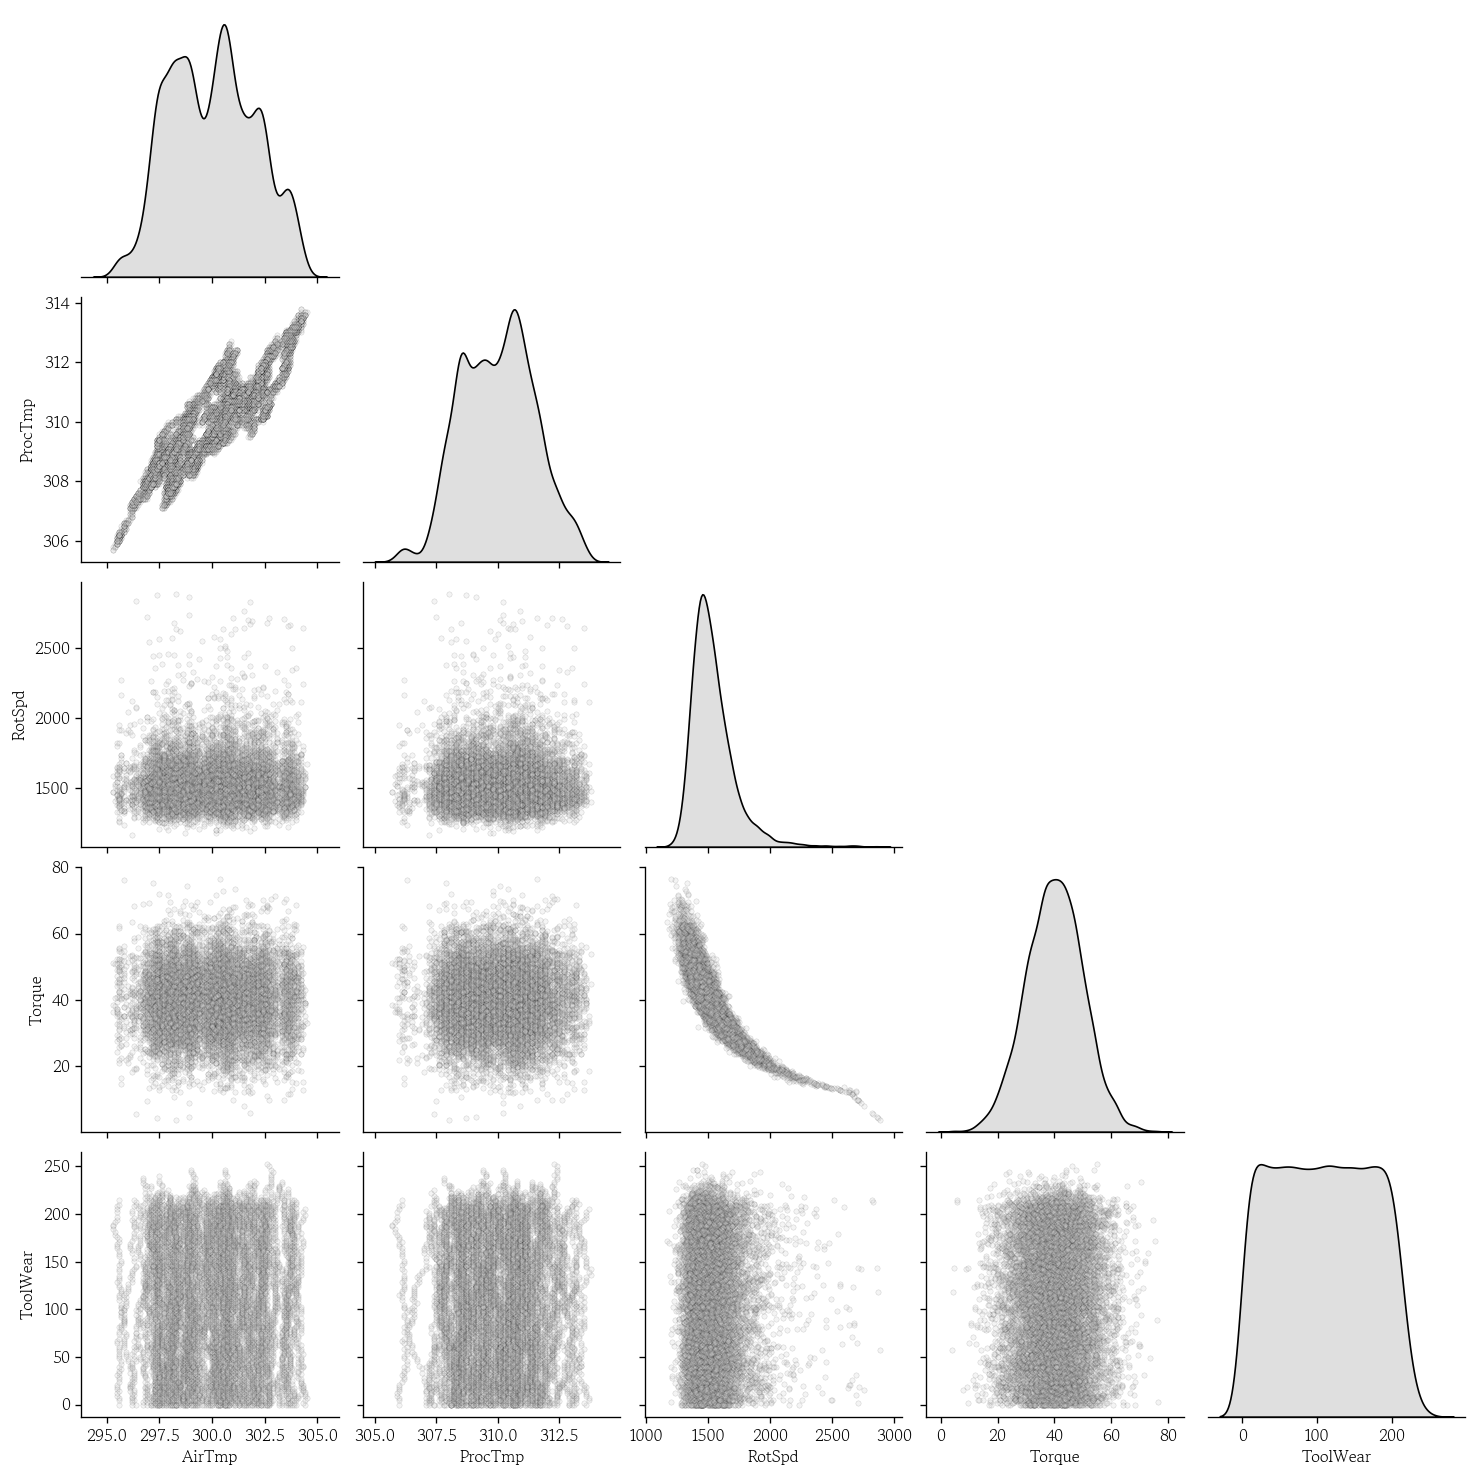

In [ ]:
sns.pairplot(
    data=train_num, diag_kind='kde', corner=True,
    diag_kws={
        'color': '0.5',
        'edgecolor': '0'
    },
    plot_kws={
        'fc': '0.8',
        'ec': '0',
        's': 10,
        'alpha': 0.2
    }
)
plt.show()

## 외부 파일로 저장

In [40]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/data'

In [41]:
pd.to_pickle(
    obj={
        'df': df,
        'train_num': train_num
    },
    filepath_or_buffer='Facility_Sensor_Raw.pkl'
)